In [1]:
!pip install xgboost

In [2]:
# Includes: Preprocessing, Hyperparameter Tuning, Comparison

# STEP 1: Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [3]:
# STEP 2: Load the dataset
# Dataset provided by user
df = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\diabetes.csv")

# Display first few rows (optional)
print("Dataset Preview:\n", df.head())

Dataset Preview:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# STEP 3: Separate features (X) and target (y)

# CHANGE THIS LINE ONLY if your target column name is different
target_column = "Outcome"

X = df.drop(columns=[target_column])
y = df[target_column]

# Encode target if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

In [6]:
# STEP 4: Handle categorical features (if any)

# Convert categorical columns into numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [7]:
# STEP 5: Train-Test Split

# Stratify ensures class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# STEP 6: Feature Scaling

# Scaling improves convergence for boosting algorithms
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# STEP 7: DEFINE BOOSTING MODELS AND THEIR HYPERPARAMETERS

# -------------------- AdaBoost --------------------
# AdaBoost focuses on misclassified samples by increasing their weights.
# It combines multiple weak learners (usually decision stumps).

ada = AdaBoostClassifier(random_state=42)

# Hyperparameters:
# n_estimators -> Number of weak learners (trees)
# learning_rate -> Controls how much each model contributes
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1, 0.5]
}

In [10]:
# -------------------- Gradient Boosting --------------------
# Gradient Boosting builds trees sequentially.
# Each new tree learns from the errors (residuals) of the previous trees.

gb = GradientBoostingClassifier(random_state=42)

# Hyperparameters:
# n_estimators -> Total number of trees
# learning_rate -> Step size for correcting errors
# max_depth -> Controls complexity of each tree
# subsample -> Uses random subset of data to reduce overfitting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}

In [11]:
# -------------------- XGBoost --------------------
# XGBoost is an optimized and regularized version of Gradient Boosting.
# It handles missing values, imbalance, and large datasets efficiently.

xgb = XGBClassifier(
    objective='binary:logistic',  # Binary classification
    eval_metric='logloss',        # Loss function
    use_label_encoder=False,
    random_state=42
)

# Hyperparameters:
# n_estimators -> Number of boosting rounds
# learning_rate -> Controls learning speed
# max_depth -> Tree complexity
# subsample -> Fraction of rows used per tree
# colsample_bytree -> Fraction of features used per tree
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

In [15]:
# STEP 8: HYPERPARAMETER TUNING USING GRIDSEARCHCV

# Dictionary to loop through all models
models = {
    "AdaBoost": (ada, ada_params),
    "Gradient Boosting": (gb, gb_params),
    "XGBoost": (xgb, xgb_params)
}

# Dictionary to store final evaluation results
results = {}

# Loop through each model
for model_name, (model, params) in models.items():
    print(f"\nTraining {model_name} with GridSearchCV...")

    # GridSearchCV tries all parameter combinations
    # cv=5 → 5-fold cross validation
    # scoring='f1' → Best for imbalanced medical datasets
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring='f1',
        cv=5,
        n_jobs=-1
    )

    # Train model on training data
    grid.fit(X_train, y_train)

    # Extract best model after tuning
    best_model = grid.best_estimator_

    # Predict on unseen test data
    y_pred = best_model.predict(X_test)

# STEP 9: MODEL EVALUATION - Moved inside the loop
    # ============================================================
    # Accuracy → Overall correctness
    # Precision → How many predicted positives are correct
    # Recall → How many actual positives are detected
    # F1-score → Balance between precision and recall
    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

    print(f"Finished training and evaluating {model_name}.")


Training AdaBoost with GridSearchCV...


C:\Users\Chinmay Pratap Dalvi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Finished training and evaluating AdaBoost.

Training Gradient Boosting with GridSearchCV...
Finished training and evaluating Gradient Boosting.

Training XGBoost with GridSearchCV...


C:\Users\Chinmay Pratap Dalvi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished training and evaluating XGBoost.


In [16]:
# STEP 10: COMPARING ALL BOOSTING MODELS

# Convert results dictionary into DataFrame
results_df = pd.DataFrame(results).T

print("\nFinal Performance Comparison of Boosting Models:\n")
print(results_df)


Final Performance Comparison of Boosting Models:

                   Accuracy  Precision    Recall  F1-Score
AdaBoost           0.746753   0.659574  0.574074  0.613861
Gradient Boosting  0.766234   0.695652  0.592593  0.640000
XGBoost            0.733766   0.627451  0.592593  0.609524


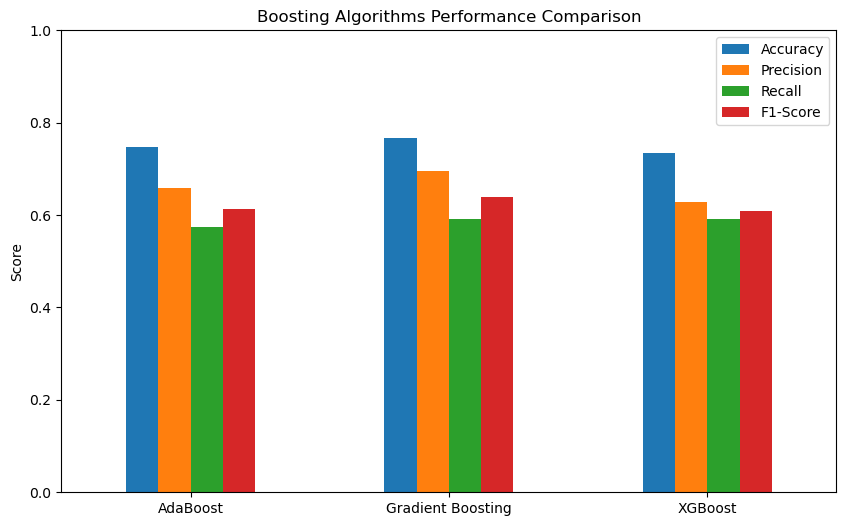

In [17]:
# STEP 11: VISUAL COMPARISON
# Bar chart helps in quick comparison of models
results_df.plot(kind='bar', figsize=(10,6))

plt.title("Boosting Algorithms Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()